In [1]:
import akshare as ak
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------------------------------
# get CSI 300 constituents
# ---------------------------------------

const = ak.index_stock_cons_csindex(symbol="000300")
tickers = const["成分券代码"].astype(str).str.zfill(6).tolist()

print("Number of stocks:", len(tickers))

# ---------------------------------------
# pull 10 years of price data
# ---------------------------------------

price_series = []
failed_tickers = []

for t in tqdm(tickers):
    try:
        df = ak.stock_zh_a_hist(
            symbol=t,
            period="daily",
            start_date="20140101",
            adjust="qfq"
        )

        if df.empty:
            failed_tickers.append(t)
            continue

        series = (
            df[["日期", "收盘"]]
            .rename(columns={"日期": "date", "收盘": t})
            .assign(date=lambda frame: pd.to_datetime(frame["date"]))
            .drop_duplicates(subset="date")
            .set_index("date")[t]
        )
        price_series.append(series)

    except Exception:
        failed_tickers.append(t)

if not price_series:
    raise RuntimeError("No price data was downloaded from AKShare.")

prices = pd.concat(price_series, axis=1, sort=True)

if failed_tickers:
    print(f"Skipped {len(failed_tickers)} tickers with missing data.")

# ---------------------------------------
# compute 200d SMA
# ---------------------------------------

sma200 = prices.rolling(200).mean()

# ---------------------------------------
# compute breadth
# ---------------------------------------

above = prices > sma200
breadth = above.sum(axis=1) / above.count(axis=1) * 100
breadth = breadth.dropna()


Number of stocks: 300


100%|██████████| 300/300 [07:13<00:00,  1.44s/it]


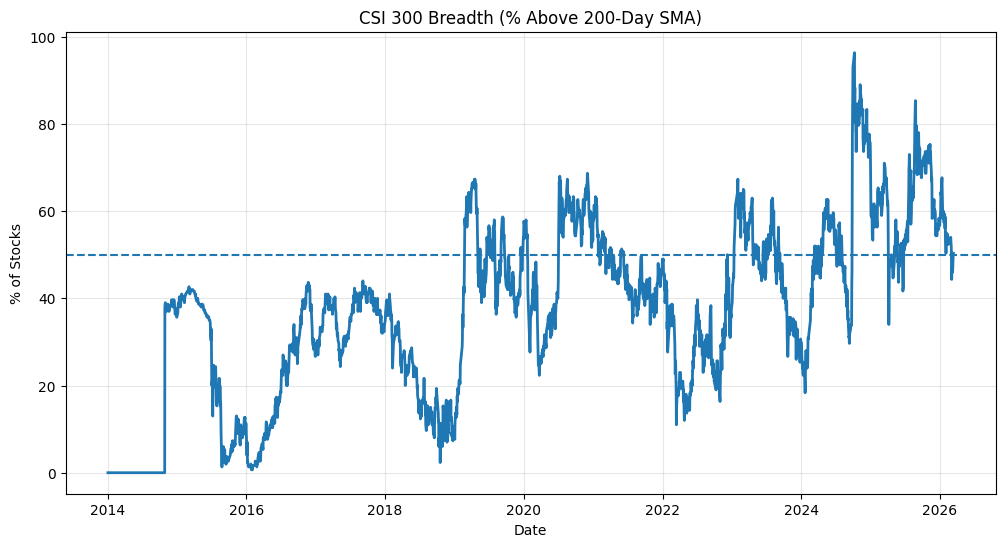

In [3]:

plt.figure(figsize=(12, 6))
plt.plot(breadth.index, breadth, linewidth=2)
plt.axhline(50, linestyle="--")
plt.title("CSI 300 Breadth (% Above 200-Day SMA)")
plt.ylabel("% of Stocks")
plt.xlabel("Date")
plt.grid(alpha=0.3)
plt.show()

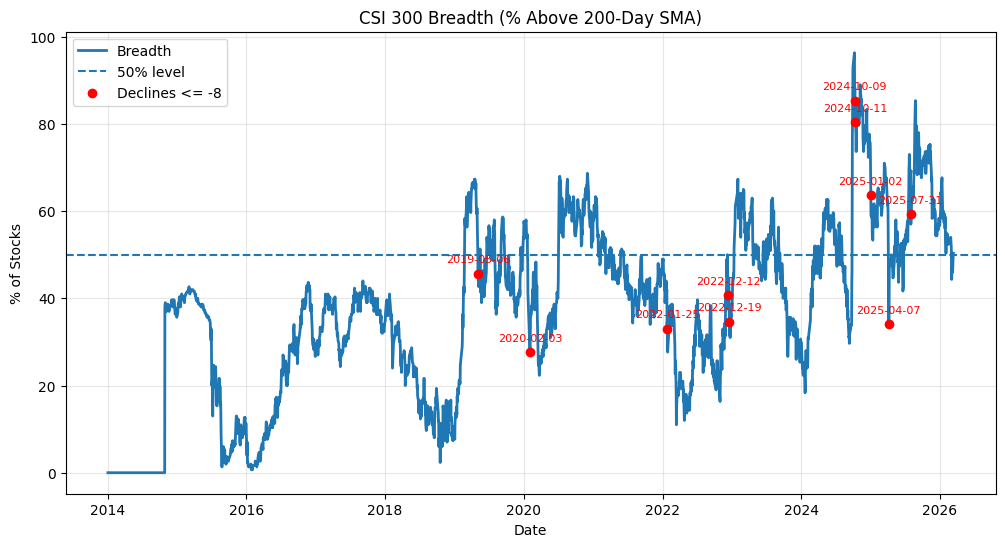

In [4]:
decline_threshold = -8

breadth = breadth.dropna()
single_day_declines = breadth.diff()
sharp_declines = single_day_declines[single_day_declines <= decline_threshold]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(breadth.index, breadth, linewidth=2, label="Breadth")
ax.axhline(50, linestyle="--", label="50% level")

if not sharp_declines.empty:
    decline_levels = breadth.loc[sharp_declines.index]
    ax.scatter(
        sharp_declines.index,
        decline_levels,
        color="red",
        zorder=3,
        label=f"Declines <= {decline_threshold}",
    )

    for date in sharp_declines.index:
        level = breadth.loc[date]
        ax.annotate(
            date.strftime("%Y-%m-%d"),
            xy=(date, level),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="red",
        )

ax.set_title("CSI 300 Breadth (% Above 200-Day SMA)")
ax.set_ylabel("% of Stocks")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.legend()

plt.show()